# Sampling a continuous-wave signal on its own Fourier basis

This tutorial builds a pulsar-timing-array model that contains a **continuous-wave (CW) source carried on its own Fourier basis** -- "Route A" -- and samples it with NUTS.

The CW is added to a Hellings-Downs (HD) gravitational-wave-background model through `ArrayLikelihood(..., extsignals=[...])`. Unlike a Gaussian process, the CW has no prior: its Fourier coefficients are a deterministic function of a few physical parameters. Because it lives on its own basis it can use *more* frequency components than the red-noise / GWB GPs, so it reaches the higher frequencies a CW search needs (the bin spacing is fixed at `1/T_obs` for every Fourier basis).

The model has four pieces:

- **per-pulsar red noise** -- a `commongp` Fourier GP
- **an HD common-process GWB** -- a `globalgp` Fourier GP
- **decentering** -- `ArrayLikelihood(decenter=True)`, which samples the GP coefficients in a whitened (unit-normal) frame
- **a CW on its own basis** -- `extsignals=[makecw_extsignal(...)]`

In [1]:
from pathlib import Path

import numpy as np
import jax
import matplotlib.pyplot as plt

import discovery as ds
from discovery import Params

## Load the pulsars

We use the first 10 pulsars from the `v1p1` feather files shipped alongside `discovery`.

In [2]:
datapath = Path(ds.__path__[0]) / '../../data'
psrs = [ds.Pulsar.read_feather(f)
        for f in sorted(datapath.glob('v1p1*.feather'))][:10]
print(f"loaded {len(psrs)} pulsars")

loaded 10 pulsars


## Build the model

`makecw_extsignal` builds the CW on its own Fourier basis with `n_cw` components. We choose `n_cw` larger than the red-noise (`n_rn`) and GWB (`n_gw`) component counts so the CW basis reaches higher frequencies.

The rest is a standard `ArrayLikelihood`: a `commongp` for per-pulsar red noise, a `globalgp` for the HD-correlated background, and `decenter=True` for whitened-frame sampling. The CW is wired in with `extsignals=[cw]`.

In [3]:
n_rn = 30   # red-noise Fourier components
n_gw = 14   # GWB Fourier components
n_cw = 60   # CW Fourier components (own basis -- larger on purpose)

T = ds.getspan(psrs)
cw = ds.makecw_extsignal(psrs, components=n_cw, T=T, pulsarterm=True)

model = ds.ArrayLikelihood(
    [ds.PulsarLikelihood([psr.residuals,
                          ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=True),
                          ds.makegp_timing(psr, svd=True)])
     for psr in psrs],
    commongp=ds.makecommongp_fourier(psrs, ds.powerlaw, components=n_rn,
                                     T=T, name='red_noise'),
    globalgp=ds.makeglobalgp_fourier(psrs, ds.powerlaw, ds.hd_orf, components=n_gw,
                                     T=T, name='gw'),
    decenter=True, extsignals=[cw])

print(f"{len(model.clogL.params)} sampled parameters "
      f"({len(cw.params)} of them CW)")

59 sampled parameters (17 of them CW)


## Evaluate the coefficient likelihood

With `decenter=True` the quantity we sample is `clogL` -- the *coefficient* likelihood, a function of the GP hyperparameters, the whitened GP coefficients, and the CW parameters. The CW enters `clogL` through GP-CW cross-terms; its parameters never touch the GP prior.

Here is a single evaluation at a test point, just to confirm the model is wired up. We draw the hyperparameters from their priors, the whitened (decentered) GP coefficients as unit normals, and fix the CW at a non-degenerate point.

In [4]:
rng = np.random.default_rng(0)
pars = ds.sample_uniform(model.logL.params)

# decentered GP coefficients are sampled in a whitened (unit-normal) frame
for psr in psrs:
    pars[f'{psr.name}_gw_coefficients({2 * n_gw})'] = rng.standard_normal(2 * n_gw)
    pars[f'{psr.name}_red_noise_coefficients({2 * n_rn})'] = rng.standard_normal(2 * n_rn)

# CW parameters at a fixed, non-degenerate point
for k in cw.params:
    if k.endswith('log10_h0'):
        pars[k] = -14.0
    elif k.endswith('log10_f0'):
        pars[k] = -7.7
    elif k.endswith('sindec') or k.endswith('cosinc'):
        pars[k] = 0.3
    elif k.endswith('phi_psr'):
        pars[k] = rng.uniform(0, 2 * np.pi)
    elif k == 'cw_phi_earth':
        pars[k] = 1.7
    else:
        pars[k] = 0.5

clogl = jax.jit(model.clogL)
P = Params.from_dict(pars, names=model.clogL.params)
print("clogL at test point =", float(clogl(P)[0]))

clogL at test point = 1088942.7303376491


## Sample with NUTS

We sample the decentered model with NUTS from `numpyro`. The sample sites are:

- `xi` -- the whitened GP coefficients, as **one array-shaped site** of shape `(npsr, 2*(n_rn + n_gw))` (not one site per pulsar)
- `gammas`, `log10_As` -- the red-noise and GWB power-law hyperparameters
- the CW earth-term parameters (`cw_log10_h0`, `cw_log10_f0`, ...)
- `cw_phi_psr` -- the per-pulsar CW pulsar-term phases

The model assembles these into the parameter dict that `clogL` expects and adds the log-likelihood with `numpyro.factor`.

In [5]:
import numpyro
import numpyro.distributions as dist
import numpyro.infer as infer

jclogl = jax.jit(model.clogL)
npsr = len(psrs)
earth = ['cw_log10_h0', 'cw_log10_f0', 'cw_ra', 'cw_sindec',
         'cw_cosinc', 'cw_psi', 'cw_phi_earth']


def cw_model():
    xi = numpyro.sample("xi", dist.Normal(0, 100).expand([npsr, 2 * (n_rn + n_gw)]))
    gammas = numpyro.sample("gammas", dist.Uniform(0, 7).expand([npsr + 1]))
    log10_As = numpyro.sample("log10_As", dist.Uniform(-20, -11).expand([npsr + 1]))

    # CW earth-term parameters
    h0 = numpyro.sample("cw_log10_h0", dist.Uniform(-18.0, -11.0))
    f0 = numpyro.sample("cw_log10_f0", dist.Uniform(-9.0, -7.0))
    ra = numpyro.sample("cw_ra", dist.Uniform(0.0, 2 * np.pi))
    sd = numpyro.sample("cw_sindec", dist.Uniform(-1.0, 1.0))
    ci = numpyro.sample("cw_cosinc", dist.Uniform(-1.0, 1.0))
    psi = numpyro.sample("cw_psi", dist.Uniform(0.0, np.pi))
    phe = numpyro.sample("cw_phi_earth", dist.Uniform(0.0, 2 * np.pi))
    phi_psr = numpyro.sample("cw_phi_psr", dist.Uniform(0, 2 * np.pi).expand([npsr]))

    pars = {f'{p.name}_red_noise_log10_A': log10_As[i] for i, p in enumerate(psrs)}
    pars.update({f'{p.name}_red_noise_gamma': gammas[i] for i, p in enumerate(psrs)})
    pars.update({'gw_log10_A': log10_As[-1], 'gw_gamma': gammas[-1]})
    pars.update({f'{p.name}_red_noise_coefficients({2 * n_rn})': xi[i, :2 * n_rn]
                 for i, p in enumerate(psrs)})
    pars.update({f'{p.name}_gw_coefficients({2 * n_gw})': xi[i, 2 * n_rn:]
                 for i, p in enumerate(psrs)})
    pars.update(dict(zip(earth, (h0, f0, ra, sd, ci, psi, phe))))
    pars.update({f'{p.name}_cw_phi_psr': phi_psr[i] for i, p in enumerate(psrs)})

    ll, _ = jclogl(pars)
    numpyro.deterministic("loglike", ll)
    numpyro.factor("ll", ll)

/Users/pmeyers/miniforge3/envs/disc_tutorial_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Run the sampler. The warmup/sample counts below are small so the tutorial finishes quickly -- increase them substantially for a production run.

In [6]:
kernel = infer.NUTS(cw_model, max_tree_depth=8, target_accept_prob=0.8)
sampler = infer.MCMC(kernel, num_warmup=200, num_samples=200, num_chains=1)
sampler.run(jax.random.key(42))
sampler.print_summary(exclude_deterministic=True)

sample: 100%|██████████| 400/400 [02:39<00:00,  2.52it/s, 127 steps of size 3.74e-02. acc. prob=0.75]


                    mean       std    median      5.0%     95.0%     n_eff     r_hat
     cw_cosinc      0.06      0.56      0.08     -0.78      0.98    200.86      1.00
   cw_log10_f0     -8.07      0.57     -8.08     -8.89     -7.12     57.39      1.00
   cw_log10_h0    -16.06      1.12    -16.15    -17.99    -14.67     43.74      1.02
  cw_phi_earth      2.88      1.64      2.81      0.29      5.32     75.94      1.00
 cw_phi_psr[0]      3.22      1.76      3.39      0.32      5.77    157.43      1.00
 cw_phi_psr[1]      3.01      1.73      3.11      0.02      5.34    149.48      1.00
 cw_phi_psr[2]      3.13      1.74      3.13      0.61      6.18     82.06      1.00
 cw_phi_psr[3]      3.10      1.84      2.86      0.52      6.03    230.63      1.03
 cw_phi_psr[4]      3.09      1.84      3.04      0.15      5.65    218.34      1.00
 cw_phi_psr[5]      3.23      1.86      3.29      0.56      5.98    157.59      0.99
 cw_phi_psr[6]      3.10      1.99      2.94      0.29      5.93

## Look at the posterior

The samples come back as a dict of arrays. As a quick look, here is the marginal posterior on the CW strain amplitude `cw_log10_h0`.

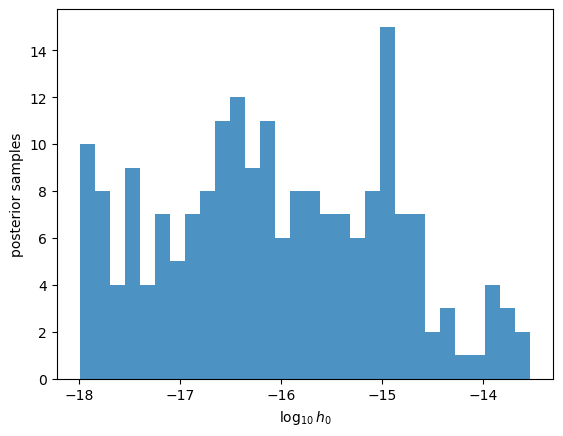

In [7]:
samples = sampler.get_samples()

plt.hist(np.asarray(samples['cw_log10_h0']), bins=30,
         histtype='stepfilled', alpha=0.8)
plt.xlabel(r'$\log_{10} h_0$')
plt.ylabel('posterior samples')
plt.show()